# GPU Programming with CuPy

*Disclaimer: Part of this notebook has been inspired by the [CuPy documentation](https://docs.cupy.dev/en/stable/)*, which is also a great resource for a more detailed description of the CuPy API.

In [1]:
import timeit
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

Santis has a node architecture where each node has four Hopper GPUs and four Grace CPUs (see [Grace Hopper Module](https://docs.cscs.ch/alps/hardware/#nvidia-gh200-gpu-nodes)). It consists of around 430 Grace-Hopper nodes connected with a network (see [Santis](https://docs.cscs.ch/clusters/santis/#cluster-specification)). Since we are currently working on one of these nodes, we have access to four GPUs, but only need 1 for the course.

Let's take a look if that's really the case. We can use the `nvidia-smi` command to inspect whether there is a GPU available.

In [2]:
%%bash
nvidia-smi

Tue Jun 17 17:59:52 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GH200 120GB             On  |   00000009:01:00.0 Off |                    0 |
| N/A   18C    P0             84W /  900W |     376MiB /  97871MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

So we can see that we have four GH200 with IDs 0-3. We can also see that we have ~98 GB of memory on each GPU. We can further see the operating temperature and the power consumption in Watt. The second box lists the programs currently running on the GPU. If at all, there might be only one entry which is our current notebook process since we have already run `import cupy` above.

We can manage all four GPUs using the ID to identify them and specifying the appropriate slurm commands. By default cupy will select ID:0 and stick with it, which is exactly what we want for our experiments.

## Hybrid Node Architecture

Each node of Santis has four Grace Hopper modules shown below. It is interesting to consider the different node-internal connections and put them into perspective. The following illustration shows the bandwidth of the connections between them and their respective memories, and the size of the memories.

![hybrid node architecture](img/cpu_gpu_bw.png)

In terms of peak floating-point throughput, the Hopper GPU (roughly 67 TFLOP/s for FP64 tensor operations) outperforms the Grace CPU (roughly <=2.5 TFLOP/s for FP64) by a factor of almost 30 (see [Slide 11](https://www.cscs.ch/fileadmin/user_upload/contents_publications/tutorials/Grace-Hopper_getting_ready.pdf)).

It is important to keep in mind that only the CPU is actually connected to the internet. And unless specific frameworks like [GPUDirect Storage](https://developer.nvidia.com/blog/gpudirect-storage/) are used, the GPU can't access the system storage directly.

## Memory Management and Data Transfer

A fundamental difficulty of GPU programming, is that the GPU and CPU memories are distinct from the programming-model point of view. This means that we have to actively manage where data is placed as well as data movement. For example, if we want to print data on the GPU to the screen, the data has to be copied from the GPU memory to the CPU memory and only then we can display it on the screen. Inversely, if we have loaded a data set from disk, it will reside in the memory of the CPU. We have to explicitly copy the data to the GPU memory before we can work on it on the GPU.

While GPUs are much faster than CPUs (higher peak FLOP/s and higher memory bandwidth), one of the main difficulties of GPU programming is making sure that the benefit of this faster processing speed is not offset by the overhead of moving the data from the CPU to the GPU and the results back.

Recent improvements in frameworks like NVLink allow for much faster CPU-GPU communication. In the bonus exercises we will investigate the complex world of [Data Movement in Tightly Coupled Heterogeneous Systems](https://arxiv.org/html/2408.11556v1) further.

Luckily, CuPy - in contrast to other GPU programming models such as CUDA or OpenACC - handles some of the memory management complexity for us. Let's start out with a simple example.

In [3]:
# create a data array in CPU memory
x_cpu = np.array([1, 2, 3])

# create a data array in GPU memory
x_gpu = cp.array([1, 2, 3])

# show values
print(x_cpu)
print(x_gpu)

[1 2 3]
[1 2 3]


Didn't we just say that we cannot print data values which reside in GPU memory? While this is true in principle, CuPy handles the copy from GPU to CPU and the print for us. But we can see that there are limits to this "illusion" when we try to assign the values of one of these arrays to the other.

In [4]:
# x_cpu[:] = x_gpu[:]  # Error

While this would be a perfectly legal operation for two regular NumPy arrays, assigning values of an array in GPU memory to an array in CPU memory cannot be done. This is very similar to the distributed memory situation where we had to use the MPI library to send messages from one rank to another in order to transfer data, because the different ranks did not share the same memory space.

The `.device` attribute contains the GPU device ID or the string cpu respectively.

In [5]:
print(x_gpu.device)  # CUDA
print(x_cpu.device)  # CPU

<CUDA Device 0>
cpu


To better understand  how cupy is handling the available GPUs we can have a look at a simple profiler output.

In order to move data from the CPU memory (host) to the GPU memory (device) we have to use the `cupy.asarray()` function. In order to move data from the GPU memory (device) back to the CPU memory (host) we can use the `get()` method of CuPy arrays.

In [7]:
del x_cpu, x_gpu

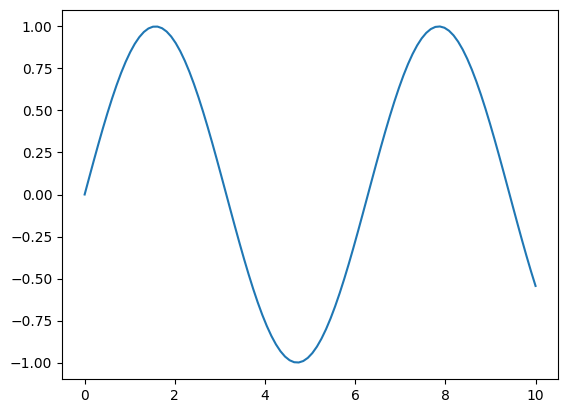

In [8]:
# generate an array on the host (CPU)
x_cpu = np.linspace(0., 10., 100)

# copy the data to the device (GPU)
x_gpu = cp.asarray(x_cpu)

# do some computation on the GPU
y_gpu = cp.sin(x_gpu)

# copy the result back to the host (CPU)
y_cpu = y_gpu.get()

# show the result
plt.plot(x_cpu, y_cpu);

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>1.</b> Define two matrices A and B of size 4096 x 4096 and initialize them with random numbers. Copy them to the GPU. Run matrix multiplication on the GPU (you can use the <tt>cp.matmul()</tt> method) and store the result in C. Copy the result back to the CPU. Validate your result using <tt>np.allclose()</tt> against a CPU reference calculation.<br>
</div>

In [9]:
# allocate and initialize matrices on CPU
a_np = np.random.rand(4096,4096)
b_np = np.random.rand(4096,4096)

# transfer matrices to GPU
a_cp = cp.asarray(a_np)
b_cp = cp.asarray(b_np)

# perform matrix-matrix multiplication on GPU
c_cp = cp.matmul(a_cp, b_cp)

# move the result back to CPU
c_np = c_cp.get()

# validate
c_ref_np = np.matmul(a_np, b_np)

assert np.allclose(c_np, c_ref_np)

# Synchronization

CuPy adopts an asynchronous model for GPU processing. This basically means that the CPU simply tells the GPU what work it would like to be done and the CuPy call returns immediately while the GPU is doing the work in the background. (For GPU enthusiasts, this means that a kernel is being launched in a stream.)

Similar to the `!$omp barrier` directive which synchronizes a team of threads and the `MPI.COMM_WORLD.Barrier()` which synchronizes a set of processes, CuPy has the `cp.cuda.Device().synchronize()` method which synchronizes CPU and GPU processing. Basically, `cp.cuda.Device().synchronize()` waits until both the GPU and the CPU have arrived at this statement in the code operation.

In [10]:
num_elements = 256 * 1024 * 1024
x_gpu = cp.random.rand(num_elements)

tic = timeit.default_timer()
y_gpu = cp.sin(x_gpu)
toc = timeit.default_timer()
elapsed_time_work = toc - tic

tic = timeit.default_timer()
cp.cuda.Device().synchronize()
toc = timeit.default_timer()
elapsed_time_sync = toc - tic

print(f"Work time = {1e6 * elapsed_time_work:.6f} µs")
print(f"Sync time = {1e6 * elapsed_time_sync:.6f} µs")

Work time = 4214.786983 µs
Sync time = 1354.605018 µs


<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>2.</b> Change the number of elements to 1 and then gradually increase back to the original value (256 x 1024 x 1024). Does the work time or sync time increase?<br>
<b>3.</b> Add another synchronization just before the first tic to make sure that the CPU and GPU are in sync. Then add another synchronization just before the first toc to make sure that the GPU has finished doing all of its work. Now run again and check how the timers behave when you change the number of elements in the data array.<br>
</div>

It is probably best to define a method for timing that we can use in the future which already includes the synchronization in order to make sure we don't forget it and our timings are off. The above example illustrates how wrong our interpretation of the performance can be if we don't take care to synchronize.

In [11]:
def get_time(sync=True):
    if sync:
        cp.cuda.Device().synchronize()
    return timeit.default_timer()

In [12]:
for i in [1, 256, 256 * 1024, 1024 * 1024, 128 * 1024 * 1024]:
    x_gpu = cp.random.rand(i)
    y_gpu = cp.asarray(x_gpu)
    tic = timeit.default_timer()
    y_gpu = cp.sin(x_gpu)
    toc = timeit.default_timer()
    elapsed_time_work = toc - tic

    tic = timeit.default_timer()
    cp.cuda.Device().synchronize()
    toc = timeit.default_timer()
    elapsed_time_sync = toc - tic

    print(f"Size {i}: Work time = {1e6 * elapsed_time_work:.6f} µs")
    print(f"Size {i}: Sync time = {1e6 * elapsed_time_sync:.6f} µs")

Size 1: Work time = 25.214977 µs
Size 1: Sync time = 10.559976 µs
Size 256: Work time = 24.800014 µs
Size 256: Sync time = 14.495978 µs
Size 262144: Work time = 21.726999 µs
Size 262144: Sync time = 10.111020 µs
Size 1048576: Work time = 24.831039 µs
Size 1048576: Sync time = 80.956961 µs
Size 134217728: Work time = 16.128004 µs
Size 134217728: Sync time = 2803.510986 µs


In [13]:
for i in [1, 256, 256 * 1024, 1024 * 1024, 256 * 1024 * 1024]:
    x_gpu = cp.random.rand(i)
    y_gpu = cp.asarray(x_gpu)
    tic = get_time()
    y_gpu = cp.sin(x_gpu)
    toc = get_time()
    elapsed_time_work = toc - tic

    tic = timeit.default_timer()
    cp.cuda.Device().synchronize()
    toc = timeit.default_timer()
    elapsed_time_sync = toc - tic

    print(f"Size {i}: Work time = {1e6 * elapsed_time_work:.6f} µs")
    print(f"Size {i}: Sync time = {1e6 * elapsed_time_sync:.6f} µs")

Size 1: Work time = 36.575017 µs
Size 1: Sync time = 3.391993 µs
Size 256: Work time = 107.516011 µs
Size 256: Sync time = 3.679947 µs
Size 262144: Work time = 24.159031 µs
Size 262144: Sync time = 3.103982 µs
Size 1048576: Work time = 25.727029 µs
Size 1048576: Sync time = 2.368004 µs
Size 268435456: Work time = 1350.446022 µs
Size 268435456: Sync time = 3.296009 µs


## Performance and Speedup

One might wonder why one would go to all the trouble of doing all of this work just to compute a `np.sin()` which we could have done much simpler without a GPU. The main reason why we want to use a GPU and are willing to go to the trouble of dealing with host / device memory management is because GPUs often allow us to do things much faster.

If you've ever run into the situation where your Python analysis script or your Fortran code simply started taking much too long for your laptop to evaluate, this is where accelerators such as GPUs come in.

In [14]:
num_elements = 64 * 1024 * 1024
x_cpu = np.random.rand(num_elements)

tic = get_time()
y_cpu = np.arctan(x_cpu)
elapsed_time_cpu = get_time() - tic

x_gpu = cp.asarray(x_cpu)

tic = get_time()
y_gpu = cp.arctan(x_gpu)
elapsed_time_gpu = get_time() - tic

speedup = elapsed_time_cpu / elapsed_time_gpu
print(f"Time CPU = {elapsed_time_cpu:.6f} s")   
print(f"Time GPU = {elapsed_time_gpu:.6f} s ({speedup:.3f}x speedup)")

Time CPU = 0.980584 s
Time GPU = 0.002073 s (473.126x speedup)


<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>4.</b> While the speedup reported above is very impressive, it neglects the time it takes to copy data to the GPU and the result back from the GPU. Insert code to copy the result back. Insert timers around the copy to the GPU and the copy back from the GPU. Make sure you synchronize before a time measurement. Add a print for the speedup relative to the total time including data movement to/from the GPU.<br>
<b>5.</b> The default is an array with 64 x 1024 x 1024 floating point values (each 8 Bytes). Compute how many MB we are transferring to the GPU and back. Compute the bandwidth in GB/s for the transfers to/from the GPU.<br>
<b>6.</b> Try out different number of elements in the array and inspect how speedup changes. What is the minimal array size for a speedup when comparing only the work and when comparing total time including data transfers? What is the maximum speedup you can achieve?<br>
<b>7. (Bonus)</b> Try it out with a simple copy, a simple stencil (e.g. <code>0.5 * (a[i+1] + a[i] + a[i-1])</code> instead. How does the maximum speedup change?
</div>

In [ ]:
elapsed_time_cpu = []
elapsed_time_gpu = []
elapsed_time_copy = []
array_bytes = []

for num_elements in 2**np.array(range(3, 28), dtype=np.int64):
    x_cpu = np.random.rand(num_elements)
    array_bytes.append(x_cpu.nbytes)

    tic = get_time()
    y_cpu = np.arctan(x_cpu)
    elapsed_time_cpu.append(get_time() - tic)

    tic = get_time()
    x_gpu = cp.asarray(x_cpu)
    elapsed_time_transfer_to = get_time() - tic

    tic = get_time()
    y_gpu = cp.arctan(x_gpu)
    elapsed_time_gpu.append(get_time() - tic)

    tic = get_time()
    y_cpu = y_gpu.get()
    elapsed_time_transfer_from = get_time() - tic

    elapsed_time_copy.append(elapsed_time_transfer_to + elapsed_time_transfer_from)

elapsed_time_cpu = np.array(elapsed_time_cpu)[2:]
elapsed_time_gpu = np.array(elapsed_time_gpu)[2:]
elapsed_time_total = elapsed_time_gpu + np.array(elapsed_time_copy)[2:]
array_bytes = np.array(array_bytes, dtype=float)[2:]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(array_bytes / 1000**2, elapsed_time_cpu / elapsed_time_gpu, "r", base=10)
ax.loglog(array_bytes / 1000**2, elapsed_time_cpu / elapsed_time_total, "b", base=10)
ax.loglog(array_bytes / 1000**2, 1.0 + 0.0 * array_bytes, "k--")
ax.set_xlabel("Array size [MB]")
ax.set_ylabel("Speedup")
ax.grid(which="major", axis="both")
ax.set_xlim([array_bytes[0] / 1000**2, array_bytes[-1] / 1000**2])
ax.legend(["Work", "Work + Transfers"])
plt.show()

In [ ]:
num_elements = 64 * 1024 * 1024
x_cpu = np.random.rand(num_elements)
array_bytes = x_cpu.nbytes

# CPU reference timing
tic = get_time()
y_cpu = np.arctan(x_cpu)
elapsed_time_cpu = get_time() - tic

# Host-to-device transfer timing
tic = get_time()
x_gpu = cp.asarray(x_cpu)
elapsed_time_transfer_to = get_time() - tic

# GPU work timing
tic = get_time()
y_gpu = cp.arctan(x_gpu)
elapsed_time_gpu = get_time() - tic

# Device-to-host transfer timing
tic = get_time()
y_cpu = y_gpu.get()
elapsed_time_transfer_from = get_time() - tic

elapsed_time_transfer = elapsed_time_transfer_to + elapsed_time_transfer_from
speedup = elapsed_time_cpu / (elapsed_time_gpu + elapsed_time_transfer)

print(f"Time CPU              = {elapsed_time_cpu:.6f} s")
print(f"Time transfer to GPU  = {elapsed_time_transfer_to:.6f} s")
print(f"Time GPU              = {elapsed_time_gpu:.6f} s")
print(f"Time transfer to CPU  = {elapsed_time_transfer_from:.6f} s")
print(f"Total GPU             = {elapsed_time_gpu + elapsed_time_transfer:.6f} s")
print(f"Speedup               = {speedup:.3f}x speedup")
print(f"Bandwidth to GPU      = {array_bytes / 1000**3 / elapsed_time_transfer_to:.3f} GB/s")
print(f"Bandwidth to CPU      = {array_bytes / 1000**3 / elapsed_time_transfer_from:.3f} GB/s")
print(f"Total transfer BW     = {2 * array_bytes / 1000**3 / elapsed_time_transfer:.3f} GB/s")

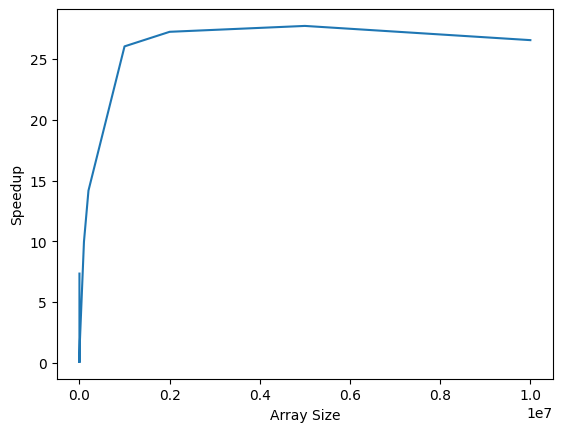

In [17]:
speedups = []
sizes = [1,2,3,4,5,6,7,8,9,10,20,50,100,1000,5000,10_000, 100_000, 200_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000]
for num_elements in sizes:
    x_cpu = np.random.rand(num_elements)

    tic = get_time()
    y_cpu = np.arctan(x_cpu)
    elapsed_time_cpu = get_time() - tic

    tic = get_time()
    x_gpu = cp.asarray(x_cpu)
    elapsed_time_transfer = get_time() - tic

    tic = get_time()
    y_gpu = cp.arctan(x_gpu)
    elapsed_time_gpu = get_time() - tic

    speedup = elapsed_time_cpu / (elapsed_time_gpu + elapsed_time_transfer)
    speedups.append(speedup)

plt.plot(sizes, speedups)
plt.xlabel('Array Size')
plt.ylabel('Speedup')
plt.show()

Text(0, 0.5, 'Speedup')

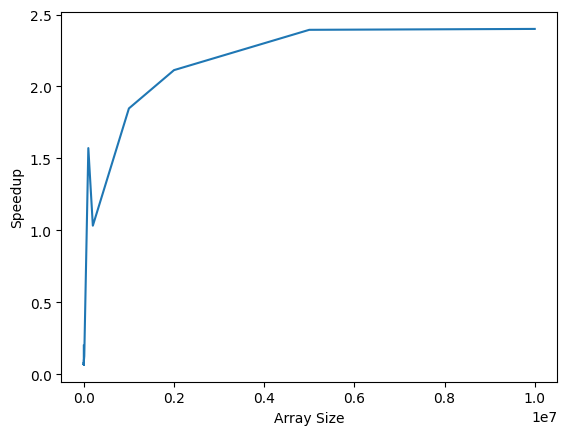

In [18]:
speedups = []
sizes = [3,4,5,6,7,8,9,10,20,50,100,1000,5000,10_000, 100_000, 200_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000]
for num_elements in sizes:
    x_cpu = np.random.rand(num_elements)

    tic = get_time()
    y_cpu = 0.5 * (x_cpu[0:-2] + x_cpu[1:-1] + x_cpu[2:])
    elapsed_time_cpu = get_time() - tic

    tic = get_time()
    x_gpu = cp.asarray(x_cpu)
    elapsed_time_transfer = get_time() - tic

    tic = get_time()
    y_gpu = 0.5 * (x_gpu[0:-2] + x_gpu[1:-1] + x_gpu[2:])
    elapsed_time_gpu = get_time() - tic

    speedup = elapsed_time_cpu / (elapsed_time_gpu + elapsed_time_transfer)
    speedups.append(speedup)

plt.plot(sizes, speedups)
plt.xlabel('Array Size')
plt.ylabel('Speedup')

## Array Programming and Vectorization (and its limits)

In order to get good performance with CuPy (and NumPy) it is key to use array programming in favor of explicit loop as much as possible. Let's compare the runtime of a vector addition (daxpy) using both array programming and an explicit loop.

In [19]:
size = 64 * 1024
for xp, backend in zip([cp, np], ["cupy", "numpy"]):

    x = xp.random.rand(size)
    y = xp.random.rand(size)
    z = xp.empty_like(x)
    a = xp.pi
  
    tic = get_time()
    z[...] = a * x + y
    elapsed_time_array = get_time() - tic
    
    tic = get_time()
    for i in range(size):
        z[i] = a * x[i] + y[i]
    elapsed_time_loop = get_time() - tic
    
    print(
        f"{backend} \t loop={elapsed_time_loop:.5f}s \t "
        f"array={elapsed_time_array:.5f}s \t speedup={elapsed_time_loop / elapsed_time_array:.3f}"
    )

numpy 	 loop=1.80224s 	 array=0.00038s 	 speedup=4788.875
cupy 	 loop=0.01718s 	 array=0.00017s 	 speedup=103.737


One can see that it is essential to use array programming notation. Both backends have a larger hit in terms of performance when calculating explicit loops over our data arrays.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>8.</b> Try writing the following motifs using array programming:
<ul>
<li>Simple stencil<br>
    $\;\;\phi_i = \left( \phi_{i-1} - 2 \, \phi_i + \phi_{i+1} \right) / \Delta x^2$<br></li>
<li>Upstream scheme<br>
    $\;\;\phi_i = \begin{cases} u_i \left( \phi_i - \phi_{i-1} \right) / \Delta x \;\;\; u_i \ge 0\\ u_i \left( \phi_{i+1} - \phi_i \right) / \Delta x \;\;\; u_i \lt 0 \end{cases}$<br></li>
<li>Maximum in neighborhood with configurable $n=3$ (assume cyclic boundary conditions)<br>
    $\;\;\phi_i = \max\limits_{j=-n,n} \phi_{i + j}$<br></li>
<li>Fixed-point iteration until converged with $\alpha = 0.01$ and $\epsilon = 1e-4$<br>
    $\;\;\mathrm{while} \,\, \left| \phi_{n+1} - \phi_{n} \right| > \epsilon:$<br>
    $\;\;\;\;\;\phi_{n+1} = (1 - \alpha) \, \phi_n + \alpha \, \phi_n^3$<br></li>
</ul>
</div>

In [20]:
size = 64 * 1024
for xp, backend in zip([cp, np], ["cupy", "numpy"]):

    u = xp.random.rand(size) - 0.5
    phi = xp.random.rand(size)
    phi_new = xp.empty_like(phi)
    dx = 0.01

    # simple stencil
    tic = get_time()
    phi_new[1:-1] = (phi[0:-2] - 2 * phi[1:-1] + phi[2:]) / dx**2
    elapsed_stencil = get_time() - tic

    # upstream scheme
    tic = get_time()
    phi_new[1:-1] = xp.where(
        u[1:-1] >= 0.0,
        u[1:-1] * (phi[1:-1] - phi[0:-2]) / dx,
        u[1:-1] * (phi[2:] - phi[1:-1]) / dx,
    )
    elapsed_upstream = get_time() - tic

    # maximum in neighborhood
    n = 3
    tic = get_time()
    phi_max = xp.roll(phi, -n)
    for shift in range(-n + 1, n + 1):
        phi_max = xp.maximum(phi_max, xp.roll(phi, shift))
    elapsed_max = get_time() - tic

    alpha = 0.01
    eps = 1.0e-4
    tic = get_time()
    phi = xp.random.rand(size // 32)
    phi_new = (1 - alpha) * phi + alpha * phi**3
    while len(xp.where(phi_new != phi)[0]) > 0:
        phi[:] = phi_new
        phi_new = (1 - alpha) * phi_new + alpha * phi_new**3
        phi_new = xp.where(xp.abs(phi_new - phi) > eps, phi_new, phi)
    elapsed_fixedpoint = get_time() - tic

    print(
        f"{backend} 	 stencil={elapsed_stencil:.5f}s 	 "
        f"upstream={elapsed_upstream:.5f}s 	 max={elapsed_max:.5f}s 	 "
        f"fixedpoint={elapsed_fixedpoint:.5f}s"
    )

cupy 	 stencil=0.00286s 	 upstream=0.00286s 	 max=0.00279s 	 fixedpoint=0.03289s
numpy 	 stencil=0.00025s 	 upstream=0.00025s 	 max=0.00043s 	 fixedpoint=0.00341s


While often it is possible to write the code using array programming (in vector form), it is not always easy. Some algorithms might actually be very hard, cumbersome or impossible to write using array programming. Typical examples are algorithms with data dependencies, algorithms with variable work depending on the position in the array, or algorithms which work on only a subset of the data array.

CuPy as well as NumPy provide some methods to extend what is possible with pure array programming syntax via the `numpy.vectorize` or the `cupy.ElementwiseKernel` and `cupy.ReductionKernel`, or even by being able to plug-in raw CUDA code (see below) by using the `cupy.RawKernel` method. Typically these methods do what we call *break the abstraction*, namely the code starts to diverge between a NumPy and a CuPy implementation, is hardware specific and no longer portable, or requires the knowledge of another programming language and is no longer part of the Python language (e.g. `cupy.RawKernel`).

## Writing CPU/GPU Agnostic Code

CuPy can serve as a drop-in replacement of NumPy in many aspects. But your code will most probably not always be running on a system where there is a GPU present. Or you would like to be able to easily switch back and forth between using NumPy and CuPy in order to test, develop and/or debug your program. A simple method of writing a CPU/GPU agnostic code is the following.

In [21]:
import numpy as np
try:
    import cupy as xp
except ImportError:
    xp = np

It is important to note that the code is slightly different from "normal" NumPy code you would write, in that you have to use the `get()` method whenever you would do a transfer from GPU memory to CPU memory (for example for plotting or for writing data to disk). Similarly, when reading data from disk you will initially have a NumPy array (irrespective of the backend you are using for `xp`) and using the method `xp.asarray()` will make sure that the data is transferred to the GPU in the case of using CuPy.

<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>9.</b> Try forcing the above code that computes a sin on a linspace to run using NumPy and CuPy and make sure that it runs with both.
</div>

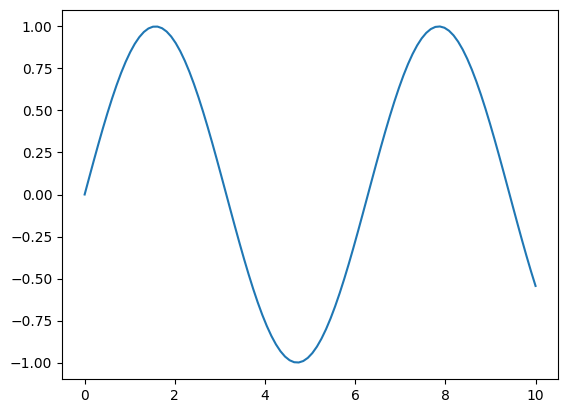

In [22]:
import numpy as np
try:
    import cupy as xp
except ImportError:
    xp = np
    
def get_array(z):
    try:
        return z.get()
    except AttributeError:
        return z

# this is a CPU/GPU agnostic program
x = xp.linspace(0., 10., 100)
y = xp.sin(x)
plt.plot(get_array(x), get_array(y));

## Low-level GPU Programming

Computations on the GPU with CuPy are extremely convenient and powerful. But it is by far not the only or most common way that GPUs are being used (and as we've seen above also has its limitations). But why can we not simply use Fortran or C/C++ to program GPUs? The reason is the same as for parallel programming with OpenMP. Most programming languages have not been designed for parallel programming and additional information from the programmer is required because the compilers are (often) not able to automatically parallelize code written in Fortran or C/C++. Furthermore, the programmer also has to explicitly manage data transfers between the CPU and the GPU, in case performance is of any importance.

#### OpenACC Directives

One popular low-level approach to GPU programming are [OpenACC](https://www.openacc.org) compiler directives which can be used in a similar fashion to OpenMP to port an existing Fortran or C/C++ code to GPU (see for example [this tutorial](https://github.com/C2SM-RCM/OpenACC_Training)). Here's an example of OpenACC when used with Fortran.

```Fortran
  ! driving routine for the physical parameterizations
  SUBROUTINE physics()
  IMPLICIT NONE

  INTEGER :: i,j    ! loop indices

  !$acc data present(t,qc,qv) 
  !$acc parallel
  !$acc loop gang
  DO j = 1,ny
  
    !$acc loop vector
    DO i = 1,nx
      DO k = 1, nlev
        v(i,j,k) = qv(i,j,k) + cs1*EXP(cs2*( t(i,j,k)-t0 )/( t(i,j,k)-cs3) )
        qc(i,j,k) = cs4*qv(i,j,k)
      END DO
      DO k = 2, nlev
        qv(i, j, k) = qv(i, j, k-1) + cm1*(t(i, j, k)-cm2)**cm3
        t(i, j, k)  = t(i, j, k)*( 1.0D0 - cm4*qc(i, j, k)+qv(i, j, k) )
      END DO
    END DO

  END DO
  !$acc end parallel
  !$acc end data
  
  END SUBROUTINE physics
```

You can see that there are `!$acc data` statements which are used for data movement / management. There is a `$!acc parallel` and a `!$acc loop` statement which is the analogue to the `!$omp parallel do` statement. 

#### CUDA

CUDA (Compute Unified Device Architecture) is an extension of the C/C++ programming language and can be used for programming GPUs from NVIDIA. Take a look at [this tutorial](https://www.nvidia.com/content/GTC-2010/pdfs/2131_GTC2010.pdf) if you would like to learn more. An example of a simple CUDA program can be seen below. The `main()` is essentially standard C/C++ except for the decoration of the invocation of the kernel function with `<<<numBlocks, blockSize>>>` and the `__global__` keyword in front of the declaration of the kernel function indicating that this is a function that should run on the GPU. Multiple threads will be running the `add()` function in parallel and in the example below an operation such as `y[i] = x[i] + 0.5 * ( y[i+1] + y[i-1] )` would be a race condition and give undefined results.

```C++
#include <iostream>
#include <math.h>

// kernel function to add the elements of two arrays
__global__
void add(int n, float *x, float *y)
{
  int index = blockIdx.x * blockDim.x + threadIdx.x;
  int stride = blockDim.x * gridDim.x;
  for (int i = index; i < n; i += stride)
    y[i] = x[i] + y[i];
}

int main(void)
{
  int N = 1<<20;
  float *x, *y;

  // allocate GPU memory
  cudaMalloc(&x, N*sizeof(float));
  cudaMalloc(&y, N*sizeof(float));

  // initialize x and y arrays (to zero)
  cudaMemset(x, 0, N*sizeof(float));
  cudaMemset(y, 0, N*sizeof(float));

  // run kernel
  int blockSize = 256;
  int numBlocks = (N + blockSize - 1) / blockSize;
  add<<<numBlocks, blockSize>>>(N, x, y);

  // free memory
  cudaFree(x);
  cudaFree(y);
  
  return 0;
}
```

#### Accessing Low-Level Programming from CuPy

CuPy allows access to low-level programming with CUDA via the `cupy.RawKernel` method. In order to use this, one has to know the CUDA programming language and have a working knowledge of how GPUs actually work. Below is an example of how one can compile a custom CUDA kernel and launch it from Python.

In [23]:
# define a kernel that adds the column vector y (1d) to all columns of x (2d)
add_and_broadcast_kernel = cp.RawKernel(
    r'''
    extern "C" __global__
    void add_and_broadcast_kernel(
        const float* x, const float* y, float* z,
        const int xdim, const int ydim)
    {
        int idx_x = blockIdx.x * blockDim.x + threadIdx.x;
        int idx_y = blockIdx.y * blockDim.y + threadIdx.y;
        z[idx_y * xdim + idx_x] = x[idx_y * xdim + idx_x] + y[idx_x];
    }
    ''',
    'add_and_broadcast_kernel'
)

# 
def launch_add_and_broadcast_kernel(x, y):
    block_size = (32, 32)
    assert x.shape[0] % block_size[0] == 0, "x.shape[0] must be a multiple of 32"
    assert x.shape[1] % block_size[1] == 0, "x.shape[1] must be a multiple of 32"
    assert y.shape[0] == x.shape[1], "y must match the second dimension of x"
    grid_size = (x.shape[1] // block_size[1], x.shape[0] // block_size[0])

    z = cp.empty(x.shape, x.dtype)
    xdim = x.strides[0] // x.strides[1]
    ydim = z.strides[0] // z.strides[1]

    add_and_broadcast_kernel(grid_size, block_size, (x, y, z, xdim, ydim))
    return z

# allocate storages on GPU
xdim = 4096
ydim = 1024
x = cp.arange(xdim * ydim, dtype=cp.float32).reshape((xdim, ydim))
y = cp.arange(ydim, dtype=cp.float32)

# run the custom kernel
z = launch_add_and_broadcast_kernel(x, y)

# verify the result
print(cp.all(x + y == z))

True


<div class="alert alert-block alert-info">
<b>Now it's your turn...</b><br>
<b>10.</b> The file  <tt>stencil2d-cupy.py</tt> is a copy of the file we used in day 1. Your goal here is to port the Python program to GPUs using CuPy and what you have learned in this notebook.<br>
<b>11.</b> Run the original <tt>stencil2d-original.py</tt> and your new GPU-enabled version for 16x16, 32x32, 64x64, 96x96 and 128x128 horizontal grid points and make a plot of speedup versus grid size.<br>
</div>

Before running the standalone scripts below, stop or restart this notebook kernel. Importing CuPy creates a CUDA context that remains open as long as the kernel lives. On Santis, GPUs are in exclusive mode, so that context can prevent another notebook or script from acquiring the GPU.

In [24]:
%%bash
# Validation of the cupy code
./validation.sh

running stencil2d.py ...
Elapsed time for work = 7.85367751121521 s
running stencil2d-cupy.py ...
Running on GPU with cupy
Elapsed time for work = 0.26680755615234375 s
running compare_fields.py ...
HOORAY! 'out_field_orig.npy' and 'out_field.npy' are equal!


In [25]:
%%bash
# TODO Exercise 10
srun -n 1 python stencil2d-cupy.py --nx=16 --ny=16 --nz=80 --num_iter=20 --plot_result=True

Running on GPU with cupy
Elapsed time for work = 0.007902860641479492 s


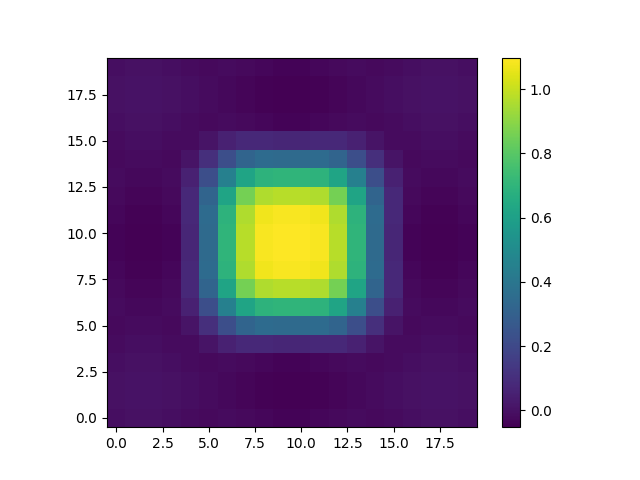

In [26]:
from IPython.display import Image, display
display(Image(filename='out_field.png'))

**Reference image for 16x16x80 for 20 steps**

![img/out_field_ref.png](img/out_field_ref.png)


In [27]:
%%bash
sizes=( 16 32 64 96 128)
for var in "${sizes[@]}"
do
   srun -n 1 python stencil2d-cupy.py --nx="${var}" --ny="${var}" --nz=80 --num_iter=5
done

Running on GPU with cupy
Elapsed time for work = 0.00201416015625 s
Running on GPU with cupy
Elapsed time for work = 0.0015234947204589844 s
Running on GPU with cupy
Elapsed time for work = 0.0021257400512695312 s
Running on GPU with cupy
Elapsed time for work = 0.001758575439453125 s
Running on GPU with cupy
Elapsed time for work = 0.0020995140075683594 s


In [28]:
%%bash
sizes=( 16 32 64 96 128)
for var in "${sizes[@]}"
do
   srun -n 1 python stencil2d-original.py --nx="${var}" --ny="${var}" --nz=80 --num_iter=5
done

Elapsed time for work = 0.0017514228820800781 s
Elapsed time for work = 0.004877567291259766 s
Elapsed time for work = 0.01825404167175293 s
Elapsed time for work = 0.04203057289123535 s
Elapsed time for work = 0.06724762916564941 s


<div class="alert alert-block alert-success">
<b>Now it's your turn...</b><br>
<b> Bonus 12 </b> Make <tt>stencil2d-agnostic.py</tt> run with CuPy when available and fall back to NumPy otherwise<br>
<b>Bonus 13</b> Combine your work for the MPI parallel version from the day3 work with the GPU-enabled version we just created. Test your program by validating the output against the serial CPU reference code and by reading the <tt>out_field.npy</tt> data from each version. If you've validated your parallel version, talk to us to give it a spin on multiple nodes on Alps. Congrats, you have just written a parallel stencil program that could potentially run on a large GPU cluster using its resources efficiently!<br>
<b>Bonus 14</b> Run <tt>memory_management.py</tt> to compare explicit pageable and pinned host buffers for host-to-device and device-to-host copies. The script also includes a small CUDA managed-memory allocation check; this managed-memory timing is not directly comparable to the copy-bandwidth numbers. You can use this paper as an overview of GH200's memory handling: https://arxiv.org/html/2408.11556v1<br>
<b>Bonus 15</b> Compiling Fortran with OpenACC is currently not supported on Alps. If you are already familiar with GPU computing, take a stab at porting the <tt>stencil2d.F90</tt> using OpenACC or the <tt>stencil2d.cpp</tt> using CUDA.<br><br>
</div>

To test multi-node performance please contact us!

In [29]:
%%bash
# TODO Exercise 12
srun -N 1 -n 1 python stencil2d-agnostic.py --nx=16 --ny=16 --nz=80 --num_iter=5

Running on GPU with cupy
Elapsed time for work = 0.0017399787902832031 s


In [30]:
%%bash
# Validation of the cupy agnostic code
./validation_agnostic.sh

running stencil2d.py ...
Elapsed time for work = 8.02039909362793 s
running stencil2d-agnostic.py ...
Running on GPU with cupy
Elapsed time for work = 0.27673840522766113 s
running compare_fields.py ...
HOORAY! 'out_field_orig.npy' and 'out_field.npy' are equal!


In [32]:
%%bash
# Validation of the cupy parallel code
./validation_parallel.sh

running stencil2d-agnostic.py ...
Running on GPU with cupy
Elapsed time for work = 1.5450096130371094 s
running stencil2d-parallel.py ...
Elapsed time for work = 1.5159733295440674 s
running compare_fields.py ...
HOORAY! 'out_field_agnostic.npy' and 'out_field.npy' are equal!


In [ ]:
%%bash
srun -N 1 -n 1 python memory_management.py

### Note for Bonus Exercise 15: Compiling Fortran with OpenACC is currently not supported on Alps
The following code cells shall be skipped for now.

In [ ]:
%%bash
module load daint-gpu
module switch PrgEnv-gnu PrgEnv-cray
module load perftools-lite

make VERSION=openacc

In [ ]:
output = !srun -N 1 -n 1 ./stencil2d-openacc.x+orig --nx 128 --ny 128 --nz 80 --num_iter 1000

In [ ]:
print(output.nlstr)

In [ ]:
output = !srun -n 6 ./stencil2d-openacc.x --nx 128 --ny 128 --nz 80 --num_iter 1000

In [ ]:
print(output.nlstr)

In [ ]:
%%bash
make clean